### 1. Импорты и загрузка

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Только стиль/палитра, без figsize
sns.set(style="whitegrid")

train = pd.read_csv("/kaggle/input/datasets/allasr/data26/train.csv")
test = pd.read_csv("/kaggle/input/datasets/allasr/data26/test.csv")

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore')

Train shape: (751, 214)
Test shape: (250, 211)


### 2. Базовая информация по данным

In [10]:
def express_info(data, name='train', nans = True):
    '''Функция первичного исследования данных:
          - структура данных
          - пропуски
          - явные дубликаты
          - статистическое описание данных
       Аргументы:
          - data - датафрейм
          - name - название таблицы
          - nans флаг (True - результат пропущенных данных по столбцам)
    '''
    print(f'Размер данных ({name}):      {data.shape}')
    print(f'Количество явных дубликатов: {data.duplicated().sum()}')
    print(f'Наличие пропусков:           {data.isna().sum().sum()}')
    if nans:
        print(f'\nПропущенные данные:')
        #print(round(data.isna().mean()*100).sort_values(ascending=False).head(7), sep = '\n')
        print(data.isna().sum().sort_values(ascending=False).head(15), sep = '\n')        
    print(f'\nИнформация ({name}):')
    data.info()
    display(data.head(5))
    display(data.describe())
    print()

express_info(train, name='train', nans = True)
express_info(test, name='test', nans = True)

Размер данных (train):      (751, 214)
Количество явных дубликатов: 0
Наличие пропусков:           24

Пропущенные данные:
MaxAbsPartialCharge    2
MinAbsPartialCharge    2
MaxPartialCharge       2
MinPartialCharge       2
BCUT2D_MWLOW           2
BCUT2D_MWHI            2
BCUT2D_MRLOW           2
BCUT2D_MRHI            2
BCUT2D_LOGPLOW         2
BCUT2D_LOGPHI          2
BCUT2D_CHGLO           2
BCUT2D_CHGHI           2
qed                    0
SPS                    0
MaxEStateIndex         0
dtype: int64

Информация (train):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 751 entries, 0 to 750
Columns: 214 entries, index to fr_urea
dtypes: float64(107), int64(107)
memory usage: 1.2 MB


,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,...,1,0,0,0,0,0,0,0,0,0
1,1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,...,0,1,0,0,0,0,0,0,0,0
2,2,4.437964,50.085589,11.285714,5.366084,5.366084,0.522930,0.522930,0.612606,24.608696,...,0,0,0,0,0,0,0,0,0,0
3,3,6.827881,682.788051,100.000000,13.317130,13.317130,0.020658,-4.829339,0.345823,12.400000,...,0,0,1,0,0,0,0,0,0,0
4,4,2.003253,70.001455,34.943894,6.320833,6.320833,0.300347,0.300347,0.562066,60.272727,...,0,0,0,0,0,0,0,0,0,0


,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
count,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,...,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.0,751.000000,751.000000,751.000000
mean,375.000000,204.544021,577.426098,89.153313,10.860070,10.860070,0.180064,-0.971890,0.577938,29.588010,...,0.055925,0.013316,0.010652,0.001332,0.001332,0.054594,0.0,0.069241,0.182423,0.006658
std,216.939316,370.367937,641.515163,788.882198,3.347314,3.347314,0.169163,1.594491,0.214190,12.713195,...,0.272400,0.114699,0.102728,0.036491,0.036491,0.227337,0.0,0.254033,1.227468,0.081377
min,0.000000,0.003517,0.700808,0.011489,2.321942,2.321942,0.000039,-6.992796,0.059567,9.545455,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
25%,187.500000,13.222351,99.998894,1.500000,8.921032,8.921032,0.048473,-1.333831,0.442842,18.306020,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
50%,375.000000,44.069306,376.580899,4.000000,12.197500,12.197500,0.121372,-0.419485,0.636477,29.281250,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
75%,562.500000,206.787402,877.508784,17.372463,13.214245,13.214245,0.290990,0.072488,0.742483,38.875000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
max,750.000000,4095.188563,4538.976189,15620.600000,15.933463,15.933463,1.374614,1.374614,0.947265,60.272727,...,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,20.000000,1.000000



Размер данных (test):      (250, 211)
Количество явных дубликатов: 0
Наличие пропусков:           12

Пропущенные данные:
MinPartialCharge       1
MaxAbsPartialCharge    1
MinAbsPartialCharge    1
MaxPartialCharge       1
BCUT2D_MRHI            1
BCUT2D_LOGPLOW         1
BCUT2D_LOGPHI          1
BCUT2D_CHGLO           1
BCUT2D_CHGHI           1
BCUT2D_MWLOW           1
BCUT2D_MWHI            1
BCUT2D_MRLOW           1
MaxEStateIndex         0
index                  0
MaxAbsEStateIndex      0
dtype: int64

Информация (test):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Columns: 211 entries, index to fr_urea
dtypes: float64(104), int64(107)
memory usage: 412.2 KB


,index,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,13.761882,13.761882,0.121946,-0.962625,0.770057,30.580645,450.541,432.397,450.070799,...,1,0,0,0,0,0,0,1,0,0
1,1,13.224489,13.224489,0.066132,-1.801871,0.278628,25.687500,448.380,428.220,448.100561,...,0,0,0,0,0,0,0,0,0,0
2,2,6.191528,6.191528,0.445278,0.445278,0.657472,55.384615,179.307,158.139,179.167400,...,0,0,0,0,0,0,0,0,0,0
3,3,14.061236,14.061236,0.054870,-6.660336,0.564307,23.464286,410.289,397.185,410.086525,...,0,0,0,0,0,0,0,0,0,0
4,4,12.790378,12.790378,0.320463,-1.642616,0.696213,22.000000,280.279,268.183,280.073559,...,0,0,0,0,0,0,0,0,0,0


,index,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
count,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,...,250.000000,250.000000,250.000000,250.0,250.0,250.000000,250.0,250.000000,250.00000,250.000000
mean,124.500000,10.746226,10.746226,0.182532,-0.953260,0.587845,29.187523,335.810320,312.690832,335.501830,...,0.048000,0.008000,0.004000,0.0,0.0,0.044000,0.0,0.072000,0.27200,0.008000
std,72.312977,3.189955,3.189955,0.167665,1.571574,0.206474,12.852043,119.724941,113.678440,119.612128,...,0.214195,0.089263,0.063246,0.0,0.0,0.205507,0.0,0.259006,1.17795,0.089263
min,0.000000,2.599352,2.599352,0.001173,-6.992796,0.079916,9.416667,151.253000,134.117000,151.136100,...,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.00000,0.000000
25%,62.250000,9.887594,9.887594,0.053571,-1.333827,0.472607,18.930233,251.667000,239.177000,251.479268,...,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.00000,0.000000
50%,124.500000,11.882133,11.882133,0.136327,-0.419785,0.632086,29.817547,305.378500,283.689500,305.163497,...,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.00000,0.000000
75%,186.750000,13.022136,13.022136,0.291678,0.052681,0.737375,38.125000,399.250750,366.158250,398.968178,...,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.00000,0.000000
max,249.000000,15.933463,15.933463,0.908843,0.908843,0.905063,60.272727,758.635000,720.331000,758.190558,...,1.000000,1.000000,1.000000,0.0,0.0,1.000000,0.0,1.000000,9.00000,1.000000


In [13]:
#Напишем функцию для проверки данных на аномалии
def feed_size(data, feature = 'middle_avg_bill', name_feature = 'средний чек', x_lim=None):
    #print(f'Данные распределением и аномалиям по {feature}')
    print(f'\nСтатистические данные о распределении значений ({name_feature}):\n')
    #display(data[feature].describe())
    plt.figure(figsize=[10, 3])
    plt.title(f'Гистограмма распределения значений ({name_feature}):', fontsize=15)
    sns.set_style('whitegrid')
    sns.histplot(data[feature], bins=70 ,  color="seagreen", label=f'{name_feature}', alpha=0.7, kde=True)
    plt.xlabel(f'{name_feature}', fontsize=12)
    plt.ylabel(f'Количество позиций', fontsize=12)
    plt.legend(loc='upper right', fontsize='large')
    plt.show()

    plt.figure(figsize=(10, 2))
    plt.title(f'\nДиаграмма рассеяния {name_feature}')
    sns.boxplot(x=data[feature], palette='pastel')  # Убрали data=...
    plt.show()


Статистические данные о распределении значений (IC50, mM):



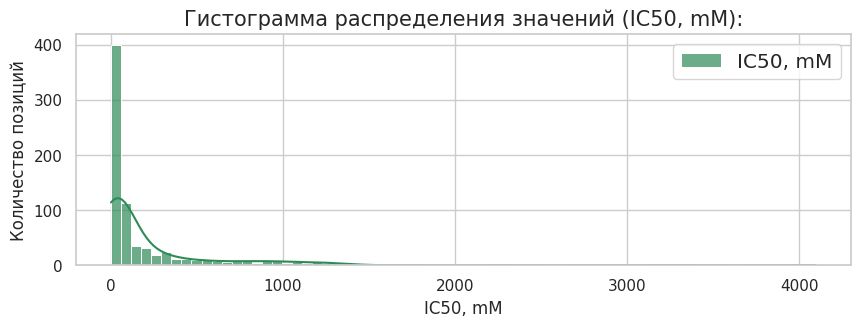

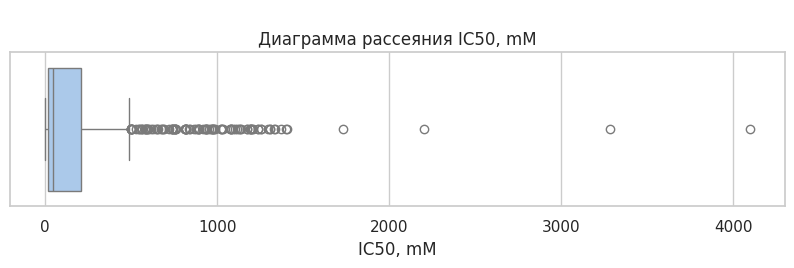


Статистические данные о распределении значений (CC50, mM):



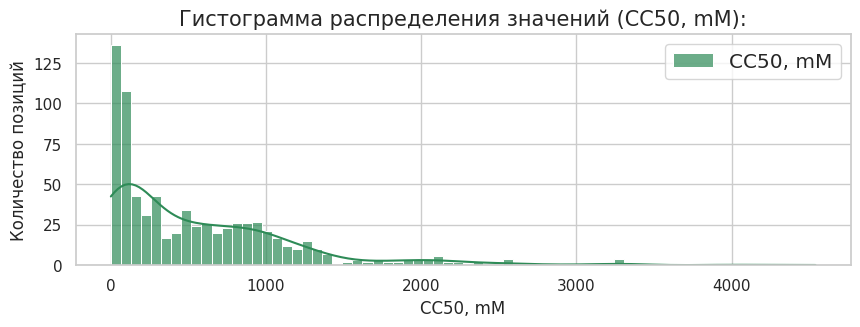

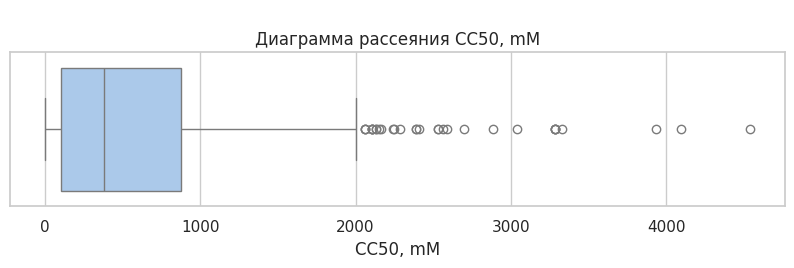


Статистические данные о распределении значений (SI):



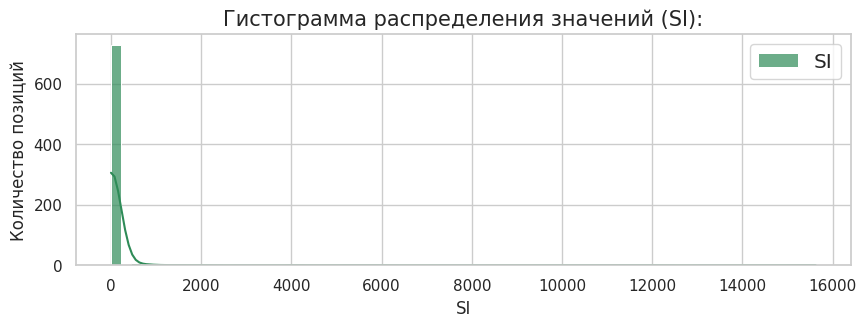

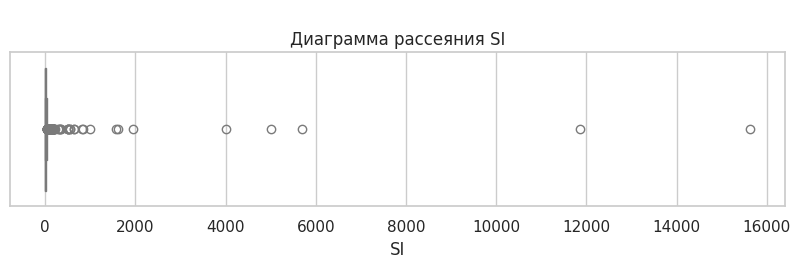

In [14]:
feed_size(train, feature = 'IC50, mM', name_feature = 'IC50, mM', x_lim=None)
feed_size(train, feature = 'CC50, mM', name_feature = 'CC50, mM', x_lim=None)
feed_size(train, feature = 'SI', name_feature = 'SI', x_lim=None)

In [56]:
# Общая информация о колонках и типах
train.info()

# Описательная статистика по таргетам
targets = ["IC50, mM", "CC50, mM", "SI"]
train[targets].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 751 entries, 0 to 750
Columns: 214 entries, index to fr_urea
dtypes: float64(107), int64(107)
memory usage: 1.2 MB


,"IC50, mM","CC50, mM",SI
count,751.000000,751.000000,751.000000
mean,204.544021,577.426098,89.153313
std,370.367937,641.515163,788.882198
min,0.003517,0.700808,0.011489
25%,13.222351,99.998894,1.500000
50%,44.069306,376.580899,4.000000
75%,206.787402,877.508784,17.372463
max,4095.188563,4538.976189,15620.600000


In [44]:
# Анализ экстремальных значений SI
si_sorted = train['SI'].sort_values(ascending=False)
print('\nСтатистика:')
print(f'quantile_99: {train['SI'].quantile(0.99):.2f}')
print(f'max = {train['SI'].max():.2f}')
print(f"Количество значений > quantile_99 = {(train['SI'] > train['SI'].quantile(0.99)).sum()}")


Статистика:
quantile_99: 1281.25
max = 15620.60
Количество значений > quantile_99 = 8


### Вывод:
- train:
    - Размер данных:  (751, 214)
    - Количество явных дубликатов: 0
    - Наличие пропусков:           24

- test:
    - Размер данных:      (250, 211)
    - Количество явных дубликатов: 0
    - Наличие пропусков:           12
- Пропуски в одних и тех же BCUT2D_* признаках — видимо специфика данных. Применим median, как наиболее простой способ, если будет время можно использовать KNN.

- Все целевые переменные IC50/CC50 имеют очень широкий диапазон и сильную асимметрию (по max и quantiles), SI тоже с длинным правым хвостом,
    - Для переменной IC50 медианное значение составляет 44.0, при этом максимальное значение достигает 4095.19, что свидетельствует о наличии крупных выбросов и длинного правого хвоста распределения (что также подтверждает боксплот). Аналогичная ситуация с CC50
    - Наиболее выраженная асимметрия наблюдается у переменной SI. При медиане 4.05 максимальное значение достигает 15620.6, что говорит о наличии экстремальных выбросов и крайне неравномерном распределении:
        - 99-й перцентиль: 1281.25
        - Максимум: 15620.60
        - Количество > 99-го перцентиля: 8
          > выбросов не так много - можно подрезать хвост (0.99), как вариант, но это может исказить данные (попробуем пока не трогать)
- Высокие значения стандартного отклонения для всех целевых переменных подтверждают большой разброс данных. Особенно это заметно для SI, где стандартное отклонение значительно превышает медиану.
- Видно, что IC50/CC50 имеют очень широкий диапазон и сильную асимметрию (по max и quantiles), SI тоже с длинным правым хвостом,
- Имеет смысл применить либо логарифмироваие, либо argtg для сглаживания хвостов, это позволит уменьшить влияние выбросов, снизить асимметрию распределений и повысить стабильность обучения модели.

## Анализ преобразования логов

#### Логарифмирование:

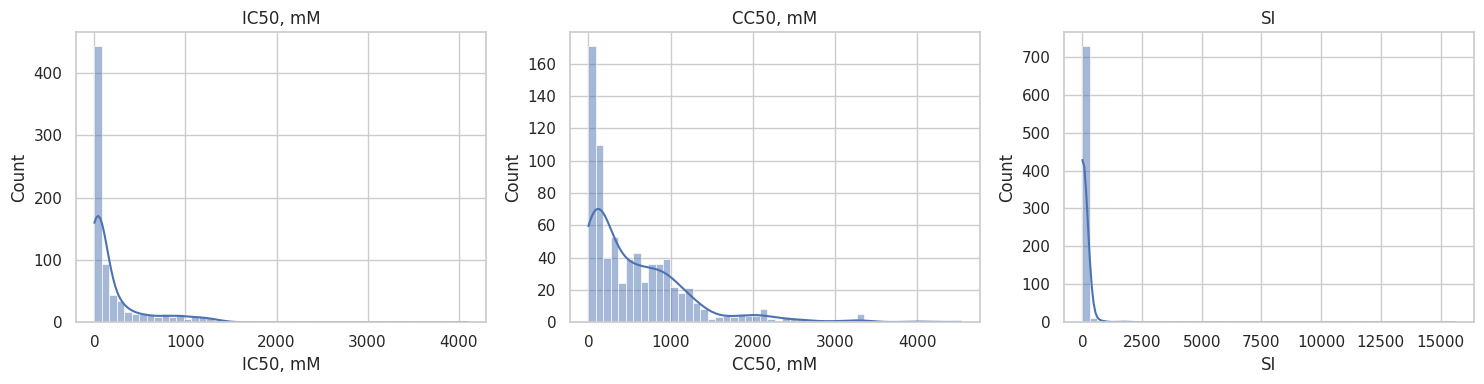

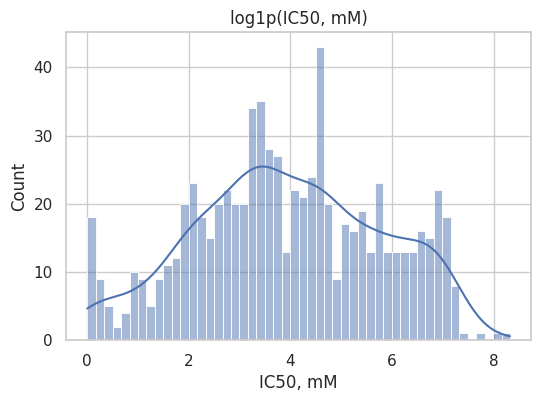

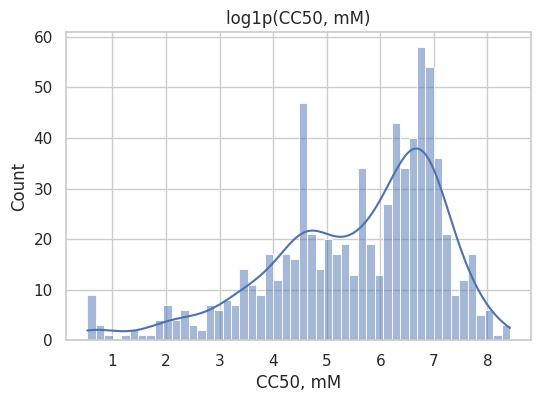

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, targets):
    sns.histplot(train[col], bins=50, kde=True, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

# Попробуем лог-распределение IC50 и CC50
for col in ["IC50, mM", "CC50, mM"]:
    plt.figure(figsize=(6, 4))
    sns.histplot(np.log1p(train[col]), bins=50, kde=True)
    plt.title(f"log1p({col})")
    plt.show()

Вывод:
– видно, что лог‑распределения более компактные, но при этом хвосты и сложная форма остаются; 
- в итоге лог‑трансформация не дала выигрыш по RMSE (мы это эмпирически проверили — скор ~340 против ~301)
- Arctan показал хорошие результаты по уменьшению асимметрии

### Применение arctan: Признаки до/после

In [29]:
# Описательная статистика по нескольким сырым признакам
feature_sample = train.columns[4:14]  # первые 10 дескрипторов после таргетов
display(train[feature_sample].describe().T)

# Применим arctan и посмотрим статистику
train_atan = np.arctan(train[feature_sample])
train_atan = pd.DataFrame(train_atan, columns=feature_sample)
train_atan.describe().T

# for col in ["IC50, mM", "CC50, mM"]:
#     plt.figure(figsize=(6, 4))
#     sns.histplot(train_atan, bins=50, kde=True)
#     plt.title(f"arctan({col})")
#     plt.show()

,count,mean,std,min,25%,50%,75%,max
MaxAbsEStateIndex,751.0,10.860070,3.347314,2.321942,8.921032,12.197500,13.214245,15.933463
MaxEStateIndex,751.0,10.860070,3.347314,2.321942,8.921032,12.197500,13.214245,15.933463
MinAbsEStateIndex,751.0,0.180064,0.169163,0.000039,0.048473,0.121372,0.290990,1.374614
MinEStateIndex,751.0,-0.971890,1.594491,-6.992796,-1.333831,-0.419485,0.072488,1.374614
qed,751.0,0.577938,0.214190,0.059567,0.442842,0.636477,0.742483,0.947265
SPS,751.0,29.588010,12.713195,9.545455,18.306020,29.281250,38.875000,60.272727
MolWt,751.0,352.407345,129.071212,110.156000,266.252000,319.129000,410.537000,904.777000
HeavyAtomMolWt,751.0,328.389832,124.072354,100.076000,246.677500,296.266000,388.318500,856.393000
ExactMolWt,751.0,352.081343,128.924918,110.073165,266.020663,318.255880,410.160797,904.248467
NumValenceElectrons,751.0,133.627164,47.173659,42.000000,102.000000,122.000000,154.000000,350.000000


,count,mean,std,min,25%,50%,75%,max
MaxAbsEStateIndex,751.0,1.462860,0.057308,1.164130,1.459165,1.488995,1.495264,1.508118
MaxEStateIndex,751.0,1.462860,0.057308,1.164130,1.459165,1.488995,1.495264,1.508118
MinAbsEStateIndex,751.0,0.172225,0.151830,0.000039,0.048436,0.120781,0.283170,0.941867
MinEStateIndex,751.0,-0.425246,0.597480,-1.428755,-0.927474,-0.397190,0.072333,0.941867
qed,751.0,0.509877,0.170199,0.059496,0.416885,0.566810,0.638673,0.758323
SPS,751.0,1.528518,0.021922,1.466415,1.516224,1.536658,1.545079,1.554207
MolWt,751.0,1.567580,0.001167,1.561719,1.567041,1.567663,1.568360,1.569691
HeavyAtomMolWt,751.0,1.567309,0.001328,1.560804,1.566742,1.567421,1.568221,1.569629
ExactMolWt,751.0,1.567577,0.001168,1.561712,1.567037,1.567654,1.568358,1.569690
NumValenceElectrons,751.0,1.562423,0.002825,1.546991,1.560993,1.562600,1.564303,1.567939


### Изменение размерности таргетов и логарифмирование

In [ ]:
def transform_targets(data, targets):
    """ Преобразование целевых значений - из милиМоль в Моль+log10p
    """
    data_transform = data.copy()
    
    # Конвертация mM - M и -log10
    for target in targets:
        # Избегаем log(0) и отрицательных значений
        M_col = target.replace("mM", "M")
        data_transform[M_col] = data[target] / 1000.0
        # Защита от нулей
        data_transform[M_col] = data_transform[M_col].clip(lower=1e-12)
        
        # p-значение
        p_col = f"p{target.split(',')[0]}"
        data_transform[p_col] = -np.log10(data_transform[M_col])
    
    # SI:  логарифмируем
    #upper_si = data["SI"].quantile(0.99) # обрезаем quantile_0.99 - опасно ддля теста потом
    #data_transform["SI_cut"] = data["SI"].clip(upper=upper_si)
    data_transform["log_SI"] = np.log1p(data_transform["SI"]) # log(1+SI)
    
    return data_transform

targets_list = ["IC50, mM", "CC50, mM"] 
train_t = transform_targets(train, targets_list)
train_t

: 

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
targets_old = ["IC50, mM", "CC50, mM", "SI"] 
for ax, col in zip(axes, targets_old):
    sns.histplot(train[col], bins=50, kde=True, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()
targets_new = ['pIC50', 'pCC50', 'log_SI']
# Попробуем лог-распределение IC50 и CC50
for col in targets_new:
    plt.figure(figsize=(6, 4))
    sns.histplot(train_t[col], bins=50, kde=True)
    plt.title(f"Размерность M+log10p({col})")
    plt.show()

In [ ]:
# определим коэффициент асимметрии распределения
display(train[targets].skew())

# Рассчитаем коэффициент асимметрии после логарифмического преобразования целевых переменных
print('\nКоэффициент асимметрии после логарифмического преобразования целевых переменных')
display(np.log1p(train[targets]).skew())

print('\nКоэффициент асимметрии после arctan преобразования целевых переменных')
display(np.arctan(train[targets]).skew())

print('\nКоэффициент асимметрии после преобразования Моль+(-log10p) и log lkz SI')
train_t[targets_new].skew()

#### Вывод:
– Исходные дескрипторы имеют большие разбросы и выбросы; 
- После arctan значения сжимаются в компактный диапазон, но порядок сохраняется — это хорошо для стабильности, но может потеряться часть информации (нужно об этом помнить).
  > Деревьям проще строить сплиты, а итоговый скор стал лучше:\
        - без arctan + без PCA ≈ 306.7\
        - с arctan + без PCA ≈ 302.2
- после преобразования Моль+(-log10p) и log lkz SI: скошенность ушла, асимметрия:
    - pIC50: 0.81 (умеренная)    
    - pCC50: 1.07 (умеренная)   
    - log_SI: 1.54 (всё ещё высокая)
    > Проблема: SI всё ещё сильно асимметричен из-за экстремальных выбросов (max 15620), пока не будем подрезать хвост, если будут плохие результаты проверим этот вариант.
- будем тестировать все наборы данных, но большая вероятность, что именно последний набор данных должен дать лучший результат.

### Корреляции между признаками

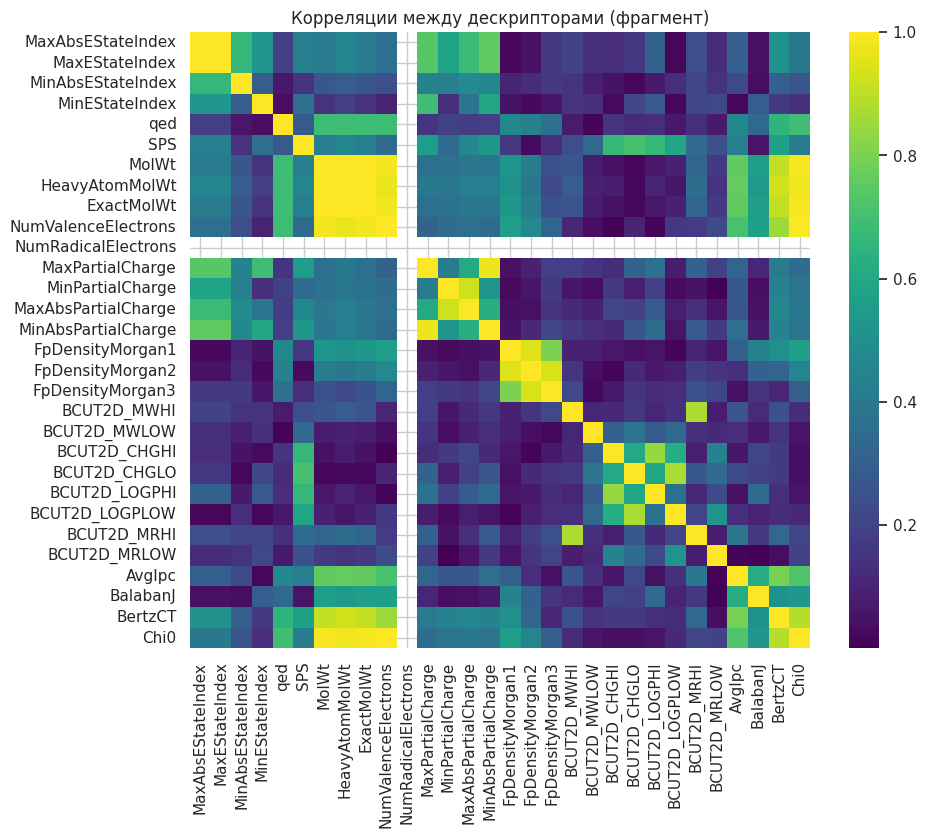

In [30]:
from itertools import islice

# Считаем матрицу корреляций по модулю для части признаков
num_features = train.columns[4:]
corr = train[num_features].corr().abs()

plt.figure(figsize=(10, 8))
sns.heatmap(corr.iloc[:30, :30], cmap="viridis")  # первые 30 фичей
plt.title("Корреляции между дескрипторами (фрагмент)")
plt.show()

#### Вывод:
– видно сильные блоки высоких корреляций между дескрипторами (RDKit генерирует семейства очень похожих фич).
– это оправдывает корр‑отбор (|corr| > 0.9) в боевом пайплайне; 
  > без него модель имела бы много дублирующей информации и больше шансов переобучиться.
- Это пропуски - пустая строчка

### Корреляция таргетов (и связь SI ≈ CC50/IC50)

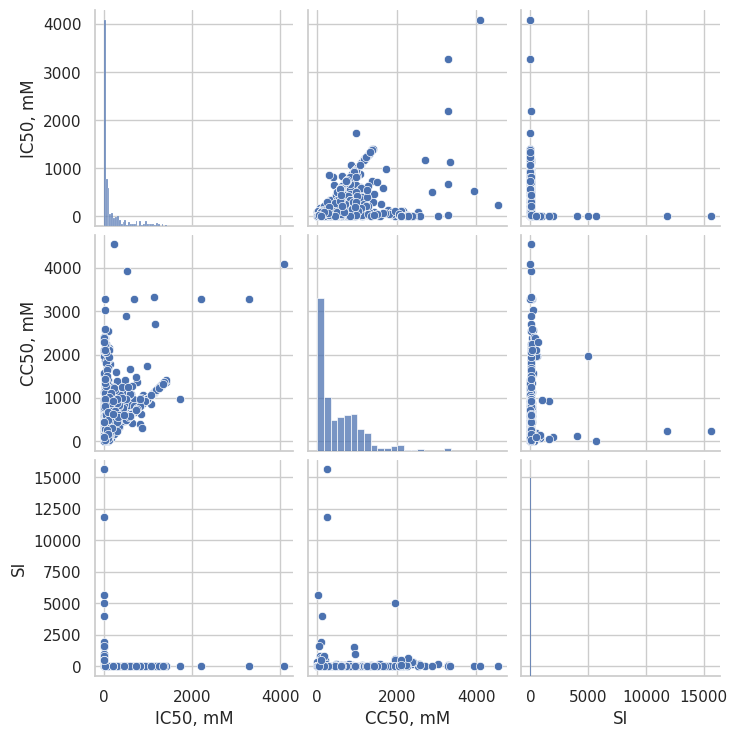

count    7.510000e+02
mean     5.927787e-14
std      8.371712e-13
min      0.000000e+00
25%      0.000000e+00
50%      4.440892e-16
75%      1.776357e-15
max      2.000888e-11
dtype: float64


In [31]:
sns.pairplot(train[targets])
plt.show()

# Проверим связь SI и отношения CC50/IC50
si_check = train["CC50, mM"] / train["IC50, mM"]
diff = (si_check - train["SI"]).abs()

print(diff.describe())

#### Вывод:
– SI почти равен CC50/IC50 (разница лежит близко к нулю).
    
    > это подтверждает, что SI редундантен с IC50/CC50.

– мы сознательно продолжаем предсказывать все три таргета отдельно, чтобы не городить ручные зависимости, но это объясняет, почему улучшения по одному таргету автоматически отражаются в SI

### Сравнение успешного и неудачных решений (текстом)

- Неудачные/менее удачные идеи:

    - PCA 80/120 компонент: давал скор 324–322 - потеря информации при сжатии, хотя матемatically аккуратен.
    
    - Лог‑таргеты IC50/CC50: вместо улучшения дали ≈340 - модель стала хуже описывать значения в исходной шкале, а RMSE в ней и считается.

- Удачная комбинация:
    - arctan по фичам:
       > корр‑отбор (|corr| > 0.9) → SimpleImputer + StandardScaler → LGBM без PCA, с небольшими деревьями (num_leaves=15, min_data_in_leaf=20), дала ~301 на public

- На улучшение:
    - Имеет смысл попробовать изметить размерность и в дальнейшем преобразовать:
        - IC50_M = IC50_mM / 1000          # миллимоль → моль
        - pIC50 = -log10(IC50_M)           # стандартная формула
        - CC50_M = CC50_mM / 1000          # миллимоль → моль
        - pCC50 = -log10(CC50_M)           # стандартная формула

# Часть 2 - подготовка признаков и обучение модели

## Обработка пропусков